#### Feature engineering 
Feature engineering means creating new useful columns from the existing data so that we can answer business questions more easily.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import pandas as pd

cleaned_data = pd.read_csv(
    "../data/processed/cleaned_transactions.csv"
)

cleaned_data["InvoiceDate"] = pd.to_datetime(
    cleaned_data["InvoiceDate"]
)

sales_data = cleaned_data[
    (cleaned_data["Quantity"] > 0) &
    (cleaned_data["Price"] > 0)
].copy()

print(sales_data.shape)

(1007914, 8)


In [33]:
# Create Revenue for each sales transaction
sales_data["Revenue"] = (
    sales_data["Quantity"] * sales_data["Price"]
)

# Check the result
sales_data[["Quantity", "Price", "Revenue"]].head()
# Check whether Revenue was calculated correctly
print(
    "Negative revenue:",
    (sales_data["Revenue"] < 0).sum()
)

print(
    "Zero revenue:",
    (sales_data["Revenue"] == 0).sum()
)

Negative revenue: 0
Zero revenue: 0


#### Important: 
- We are not supposed to depend on variables from another notebook. Each notebook should load the data it needs. 
- WHY?
- Each notebook has its own Python session, so variables like sales_data don't automatically carry over.
- Saving/loading the processed data makes each notebook independent and reproducible.

In [34]:
# Create date and time features
sales_data["Year"] = sales_data["InvoiceDate"].dt.year
sales_data["Month"] = sales_data["InvoiceDate"].dt.month
sales_data["Month_Name"] = sales_data["InvoiceDate"].dt.month_name()
sales_data["Day"] = sales_data["InvoiceDate"].dt.day
sales_data["Hour"] = sales_data["InvoiceDate"].dt.hour

In [4]:
sales_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Month_Name,Day,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,December,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,December,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,December,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,December,1,7


In [35]:
customer_data = sales_data.groupby("Customer ID").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Orders=("Invoice", "nunique"),
    Total_Quantity=("Quantity", "sum")
)
customer_data.head()

,Total_Revenue,Total_Orders,Total_Quantity
Customer ID,,,
12346.0,77556.46,12,74285
12347.0,4921.53,8,2967
12348.0,2019.40,5,2714
12349.0,4428.69,4,1624
12350.0,334.40,1,197


In [36]:
product_data = sales_data.groupby("StockCode").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Orders=("Invoice", "nunique"),
    Total_Quantity=("Quantity", "sum")
)
product_data.head()

,Total_Revenue,Total_Orders,Total_Quantity
StockCode,,,
10002,6942.26,362,8671
10002R,20.57,3,4
10080,129.29,27,315
10109,1.68,1,4
10120,142.74,73,664


In [37]:
# Final validation

print("Sales data shape:", sales_data.shape)
print("Duplicate rows:", sales_data.duplicated().sum())
print("Negative revenue:", (sales_data["Revenue"] < 0).sum())
print("Zero revenue:", (sales_data["Revenue"] == 0).sum())
print("Missing Revenue:", sales_data["Revenue"].isnull().sum())

print("\nCustomer data shape:", customer_data.shape)
print("Product data shape:", product_data.shape)


Sales data shape: (1007914, 14)
Duplicate rows: 0
Negative revenue: 0
Zero revenue: 0
Missing Revenue: 0

Customer data shape: (5878, 3)
Product data shape: (4917, 3)


In [38]:
sales_data.to_csv(
    "../data/processed/sales_features.csv",
    index=False
)
customer_data.to_csv(
    "../data/processed/customer_summary.csv",
    index=False
)

product_data.to_csv(
    "../data/processed/product_summary.csv",
    index=False
)

In [39]:
# Overall sales metrics

total_revenue = sales_data["Revenue"].sum()
total_orders = sales_data["Invoice"].nunique()
total_quantity = sales_data["Quantity"].sum()
average_order_value = total_revenue / total_orders

sales_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_quantity,
        average_order_value
    ]
})

sales_summary

,Metric,Value
0,Total Revenue,2.047663e+07
1,Total Orders,4.007800e+04
2,Total Quantity Sold,1.120515e+07
3,Average Order Value,5.109196e+02


#### PRODUCT ANALYSIS

In [40]:
# foundation for our monthly revenue trend.
monthly_sales = (
    sales_data.groupby(["Year", "Month", "Month_Name"])["Revenue"]
    .sum()
    .reset_index()
)
monthly_sales = monthly_sales.sort_values(
    ["Year", "Month"]
)

monthly_sales.head()

,Year,Month,Month_Name,Revenue
0,2009,12,December,822483.950
1,2010,1,January,651155.112
2,2010,2,February,551878.296
3,2010,3,March,830915.261
4,2010,4,April,678875.252


In [24]:
top_products_revenue = (
    product_data
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)
top_products_revenue.head()

,Total_Revenue,Total_Orders,Total_Quantity
StockCode,,,
M,339599.81,785,9630
22423,330590.32,3918,26478
DOT,309854.11,1415,1415
85123A,257724.71,5365,94203
85099B,180569.34,3989,96757


In [25]:
top_products_quantity = (
    product_data
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
)
top_products_quantity.head()

,Total_Revenue,Total_Orders,Total_Quantity
StockCode,,,
84077,24445.61,1019,106139
85099B,180569.34,3989,96757
21212,51825.15,3118,94884
85123A,257724.71,5365,94203
22197,79520.20,2322,88499


#### CUSTOMERS ANALYSIS

In [17]:
top_customers = (
    customer_data
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)
top_customers

,Total_Revenue,Total_Orders,Total_Quantity
Customer ID,,,
18102.0,580987.04,145,181645
14646.0,528602.52,151,367193
14156.0,313437.62,156,164325
14911.0,291420.81,398,147972
17450.0,244784.25,51,83914
13694.0,195640.69,143,188201
17511.0,172132.87,60,117174
16446.0,168472.50,2,80997
16684.0,147142.77,55,104810


In [18]:
# Top 10 customers by number of orders

top_customers_orders = (
    customer_data
    .sort_values("Total_Orders", ascending=False)
    .head(10)
)
top_customers_orders

,Total_Revenue,Total_Orders,Total_Quantity
Customer ID,,,
14911.0,291420.81,398,147972
12748.0,53539.64,336,37109
17841.0,68545.25,211,36584
15311.0,114966.42,208,70149
13089.0,113416.91,203,58932
14606.0,29951.37,192,15217
14156.0,313437.62,156,164325
17850.0,51208.87,155,21052
14646.0,528602.52,151,367193


In [58]:
top_customers_revenue = (
    customer_data
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)
top_customers_revenue

,Total_Revenue,Total_Orders,Total_Quantity
Customer ID,,,
18102.0,580987.04,145,181645
14646.0,528602.52,151,367193
14156.0,313437.62,156,164325
14911.0,291420.81,398,147972
17450.0,244784.25,51,83914
13694.0,195640.69,143,188201
17511.0,172132.87,60,117174
16446.0,168472.50,2,80997
16684.0,147142.77,55,104810


In [19]:
# Top 10 customers by number of orders

top_customers_quantity = (
    customer_data
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
)
top_customers_quantity

,Total_Revenue,Total_Orders,Total_Quantity
Customer ID,,,
14646.0,528602.52,151,367193
13902.0,34095.26,5,220600
13694.0,195640.69,143,188201
18102.0,580987.04,145,181645
14156.0,313437.62,156,164325
14911.0,291420.81,398,147972
17511.0,172132.87,60,117174
16684.0,147142.77,55,104810
14298.0,91194.49,82,100272


In [20]:
#how much revenue the average customer generates:
customer_data["Total_Revenue"].describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: Total_Revenue, dtype: float64

In [22]:
#customers who placed more than one order:
repeat_customers = customer_data[
    customer_data["Total_Orders"] > 1
]

print("Total customers:", len(customer_data))
print("Repeat customers:", len(repeat_customers))

repeat_customer_rate = (
    len(repeat_customers) / len(customer_data)
) * 100

print("Repeat Customer Rate:", repeat_customer_rate)

Total customers: 5878
Repeat customers: 4255
Repeat Customer Rate: 72.38856753997959


#### COUNTRY ANALYSIS

In [41]:
#which country generates most revenue
country_data = (
    sales_data.groupby("Country")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("Invoice", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

country_data.head()

,Country,Total_Revenue,Total_Orders,Total_Quantity
0,Australia,169283.46,95,103759
1,Austria,23613.01,45,11578
2,Bahrain,3109.79,10,1339
3,Belgium,65387.82,149,34768
4,Bermuda,1253.14,1,2798


In [44]:
top_countries_revenue = (
    country_data
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)
top_countries_revenue

,Country,Total_Revenue,Total_Orders,Total_Quantity
40,United Kingdom,1.741057e+07,36536,9187754
11,EIRE,6.587673e+05,626,336329
26,Netherlands,5.540381e+05,228,383879
15,Germany,4.250197e+05,789,225154
14,France,3.504561e+05,622,271901
0,Australia,1.692835e+05,95,103759
34,Spain,1.083325e+05,154,50307
36,Switzerland,1.006856e+05,93,52762
35,Sweden,9.186982e+04,105,88633
10,Denmark,6.858069e+04,43,237471


In [43]:
top_countries_order = (
    country_data
    .sort_values("Total_Orders", ascending=False)
    .head(10)
)
top_countries_order

,Country,Total_Revenue,Total_Orders,Total_Quantity
40,United Kingdom,1.741057e+07,36536,9187754
15,Germany,4.250197e+05,789,225154
11,EIRE,6.587673e+05,626,336329
14,France,3.504561e+05,622,271901
26,Netherlands,5.540381e+05,228,383879
34,Spain,1.083325e+05,154,50307
3,Belgium,6.538782e+04,149,34768
35,Sweden,9.186982e+04,105,88633
0,Australia,1.692835e+05,95,103759
30,Portugal,5.628353e+04,95,27719


In [42]:
top_countries_quantity = (
    country_data
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
)
top_countries_quantity

,Country,Total_Revenue,Total_Orders,Total_Quantity
40,United Kingdom,1.741057e+07,36536,9187754
26,Netherlands,5.540381e+05,228,383879
11,EIRE,6.587673e+05,626,336329
14,France,3.504561e+05,622,271901
10,Denmark,6.858069e+04,43,237471
15,Germany,4.250197e+05,789,225154
0,Australia,1.692835e+05,95,103759
35,Sweden,9.186982e+04,105,88633
36,Switzerland,1.006856e+05,93,52762
34,Spain,1.083325e+05,154,50307


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Monthly Revenue Trend.

In [89]:
monthly_revenue = (
    sales_data
    .groupby(["Year", "Month"])["Revenue"]
    .sum()
    .reset_index()
)
monthly_orders = (
    sales_data
    .groupby(["Year", "Month", "Month_Name"])["Invoice"]
    .nunique()
    .reset_index(name="Total_Orders")
)

#### Visualization

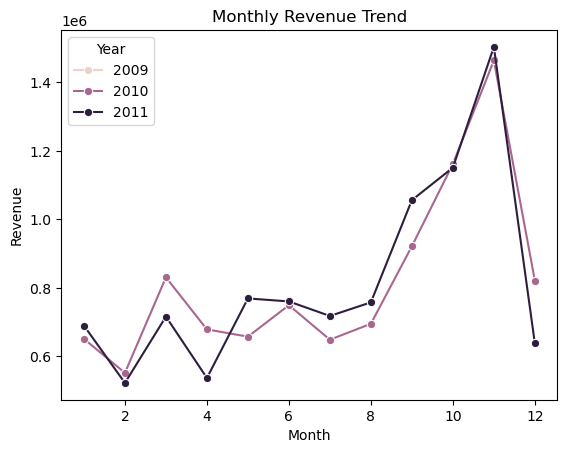

In [79]:
#seasonality and changes in revenue over time
sns.lineplot(
    data=monthly_revenue,
    x="Month",
    y="Revenue",
    hue="Year",
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.legend(title="Year")

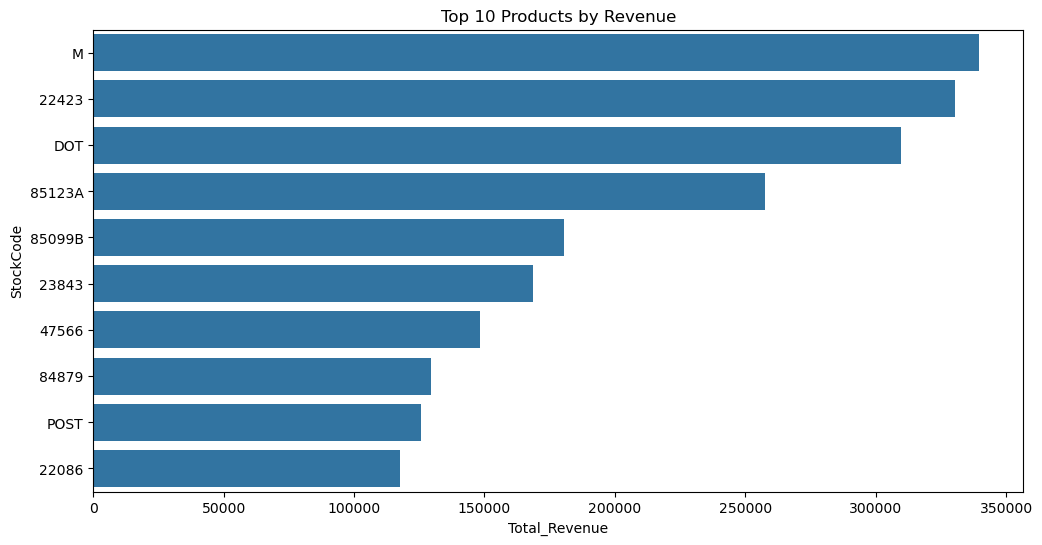

In [56]:
#Top 10 Products by Revenue
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_products_revenue,
    x="Total_Revenue",
    y="StockCode"
)
plt.title("Top 10 Products by Revenue")

Text(0.5, 1.0, 'Top 10 Customers by Revenue')

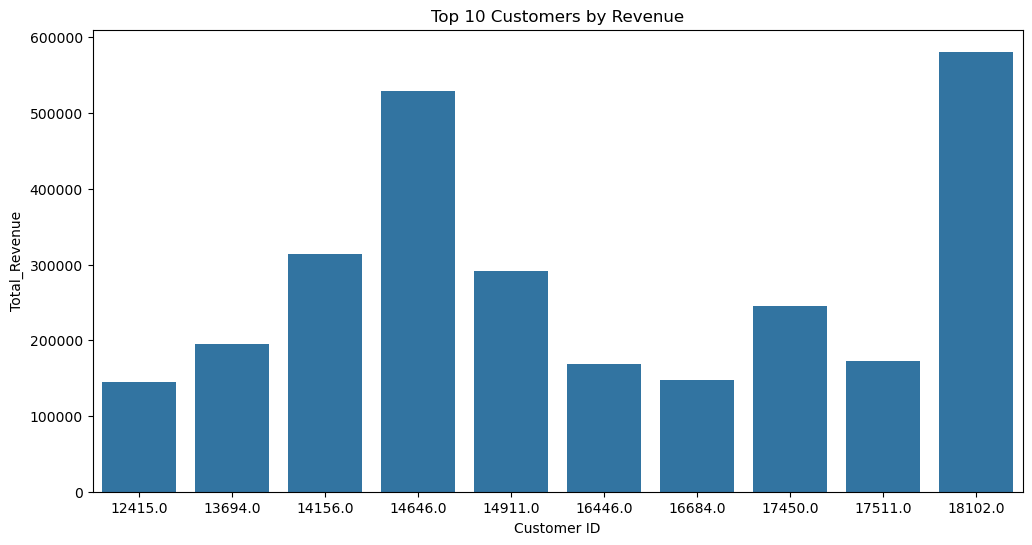

In [101]:
#Top 10 Customers by Revenue
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_customers_revenue,
    x="Customer ID",
    y="Total_Revenue"
)
plt.title("Top 10 Customers by Revenue")

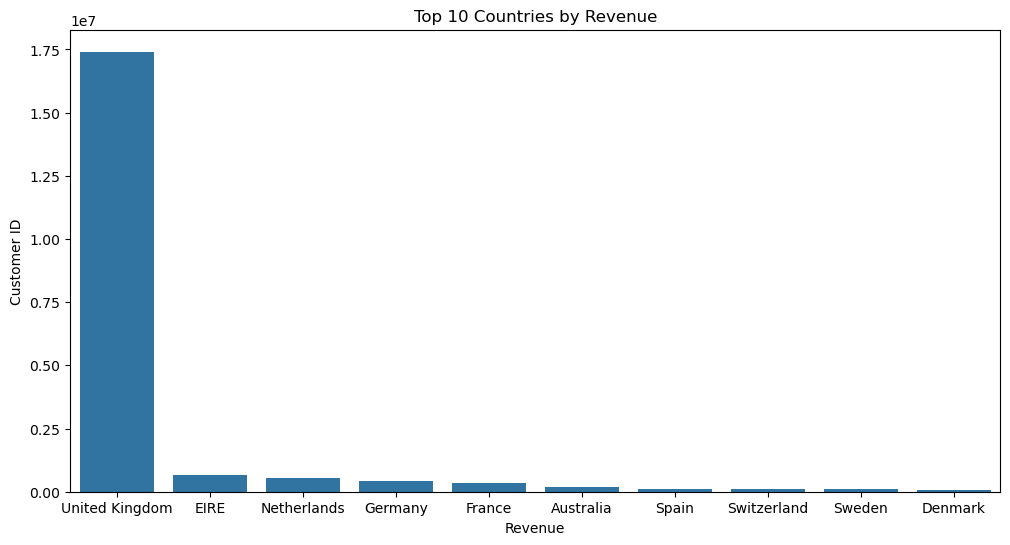

In [88]:
#Top 10 Countries by Revenue
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_countries_revenue,
    x="Country",
    y="Total_Revenue"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()

C:\Users\naina\AppData\Local\Temp\ipykernel_13772\2779110151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 1.0, 'Top 10 Products by Quantity Sold')

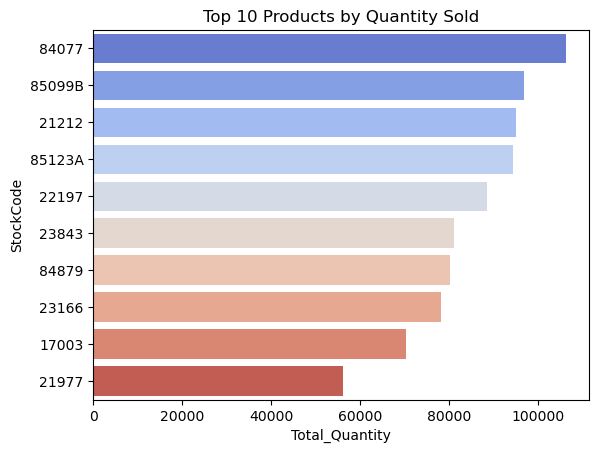

In [87]:
#Top 10 Products by Quantity Sold
sns.barplot(
    data = top_products_quantity,
    x= "Total_Quantity",
    y = "StockCode",
    palette="coolwarm"
)
plt.title("Top 10 Products by Quantity Sold")


Text(0.5, 1.0, 'Top 10 Customers by Number of Orders')

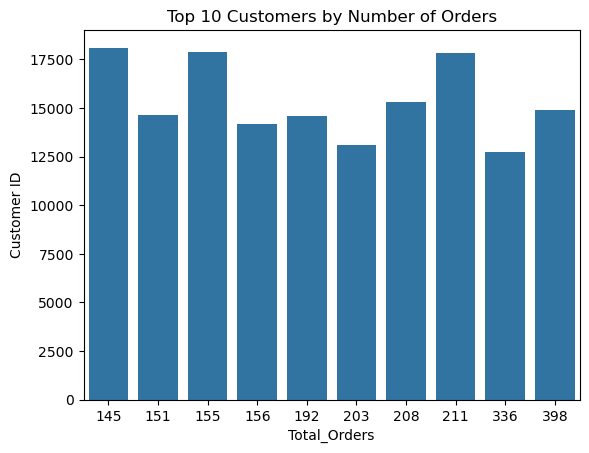

In [77]:
#Top 10 Customers by Number of Orders
sns.barplot(
    data=top_customers_orders,
    x="Total_Orders",
    y="Customer ID"
)
plt.title("Top 10 Customers by Number of Orders")

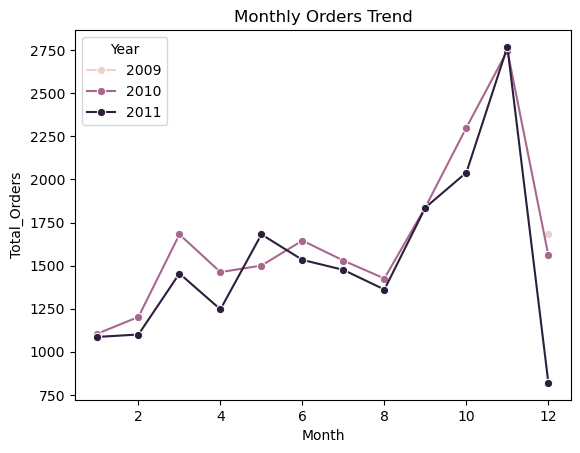

In [98]:
#Monthly Orders Trend
sns.lineplot(
    data=monthly_orders,
    x="Month",
    y="Total_Orders",
    hue="Year",
    marker="o"
)

plt.title("Monthly Orders Trend")
plt.legend(title="Year")


Text(0.5, 1.0, 'Revenue vs Quantity by Product')

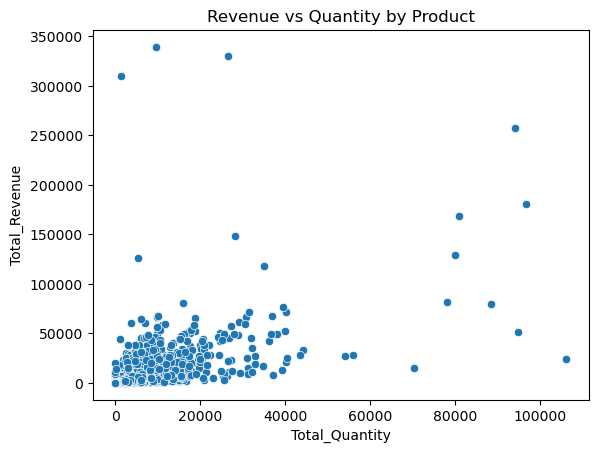

In [97]:
# Revenue vs Quantity by Product
sns.scatterplot(
    data=product_data,
    x="Total_Quantity",
    y="Total_Revenue"
)
plt.title("Revenue vs Quantity by Product")

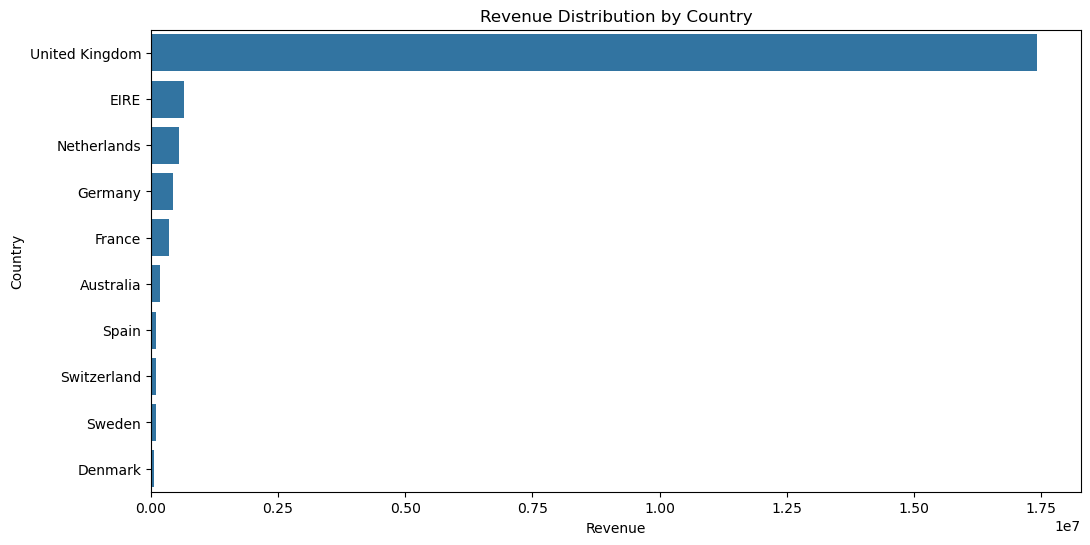

In [ ]:
# Revenue Distribution by Country
top_countries = (
    country_data
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_countries,
    x="Total_Revenue",
    y="Country"
)
plt.title("Revenue Distribution by Country")

#### Business Insights

##### 1. Overall Sales Performance

- The dataset contains total revenue of approximately 20.48 million.
- The analysis includes approximately 40,078 orders.
- The total quantity sold is approximately 11.21 million units.
- The average order value is approximately 510.92.

##### 2. Product Insights

- The top products by revenue were identified using total product revenue.
- The top products by quantity sold were identified separately.
- Comparing revenue and quantity helps identify products that have high sales volume versus products that generate higher revenue.

##### 3. Customer Insights

- The top customers by revenue were identified based on their total spending.
- Customers were also analyzed based on order frequency and quantity purchased.
- Repeat customers were identified using customers with more than one order.

##### 4. Country Insights

- The United Kingdom generated the highest revenue among the countries analyzed.
- The revenue contribution of the United Kingdom was substantially higher than the other countries in the top-10 revenue comparison.
- Country-level analysis helps identify the major geographic markets contributing to sales.

##### 5. Time-Based Insights

- Monthly revenue and order trends were analyzed to identify changes in sales activity over time.
- The monthly trends can be used to identify periods of higher and lower sales activity.

##### 6. Product Revenue vs Quantity

- The scatter plot compares product sales volume with product revenue.
- This helps identify whether higher product volume is associated with higher revenue and highlights products that behave differently from the general pattern.